# 08 — Validación: Trade-off Riesgo-Retorno (v7)

## Entradas y salidas

- Carga `recommendations_v8.parquet` (generado por N07) con fallback a versiones anteriores.
- Carga `nb06_h22_model_results.parquet` (canónico actualizado por N06a).
- Guarda resultados en `backtest_results_v7.parquet` y `backtest_summary_v7.json`.

## Objetivo

Validar empíricamente que el motor de recomendaciones produce el **trade-off correcto**
entre nivel de riesgo, predicción y retorno:

| Perfil | Vol predicha | Hit rate | Retorno |
|--------|-------------|---------|--------|
| R1 (Muy Conservador) | baja | alto | bajo |
| R5 (Muy Agresivo) | alta | bajo | alto |

## Metodología

- **Walk-forward backtest:** ventanas de 22 días desde 2007 hasta 2026
- **Hit rate:** fracción de ventanas con retorno realizado positivo


In [1]:

import sys, json, warnings
from pathlib import Path
import matplotlib
matplotlib.use('inline' if 'ipykernel' in sys.modules else 'Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('.').resolve()
for p in [ROOT, ROOT.parent]:
    if (p / 'data').exists() and (p / 'src').exists():
        ROOT = p; break
sys.path.insert(0, str(ROOT))

PROCESSED_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR   = ROOT / 'data' / 'results'
FIG_DIR       = RESULTS_DIR / 'figures'

from src.nb08_validation import (
    run_walk_forward_backtest, compute_validation_metrics, compute_by_risk,
    compute_drawdown_stats, CRISIS_WINDOWS, run_crisis_backtest,
    run_crisis_backtest_by_risk, plot_crisis_comparison,
    compare_recommendation_versions, save_backtest_outputs_v5,
)
HORIZON_DAYS = 22
LEVEL_NAMES  = {1:'Muy Conservador', 2:'Conservador', 3:'Moderado',
                4:'Agresivo', 5:'Muy Agresivo'}
print("Modulo cargado OK")

Modulo cargado OK


## 1. Cargar datos

In [2]:
# NB06 growth results (canonico, actualizado por NB06a-v8)
model_results, source_version = None, None
for tag, fname in [("v8",        "nb06v8_h22_model_results.parquet"),
                   ("canonical", "nb06_h22_model_results.parquet"),
                   ("v6",        "nb06v6_h22_model_results.parquet")]:
    p = RESULTS_DIR / fname
    if p.exists():
        model_results = pd.read_parquet(p)
        source_version = tag
        print(f"Cargado nb06 {tag}: {model_results.shape}  ({fname})")
        break
if model_results is None:
    raise FileNotFoundError("Ejecuta primero NB06a-v8")

# Recommendations (v8 preferida, fallback v7/v6/v5)
recs_df = None
for recs_fname in ["recommendations_v8.parquet", "recommendations_v7.parquet", "recommendations_v6.parquet", "recommendations_v5.parquet"]:
    p = RESULTS_DIR / recs_fname
    if p.exists():
        recs_df = pd.read_parquet(p)
        print(f"Recomendaciones: {recs_fname}  shape={recs_df.shape}")
        break
if recs_df is None:
    raise FileNotFoundError("Ejecuta primero NB07")

port_returns = pd.read_parquet(PROCESSED_DIR / "portfolios_returns.parquet")
port_returns.columns = [int(c) for c in port_returns.columns]
print(f"Portfolio returns: {port_returns.shape}  "
      f"[{port_returns.index[0].date()} -> {port_returns.index[-1].date()}]")

mape_cols = [
    ("M1", "M1_mape_pct"),
    ("M2", "M2_mape_pct"),
    ("M3", "M3_mape_pct"),
    ("M4", "M4_mape_pct"),
    ("ENS", "ENS_mape_pct"),
]
available_mape = [(label, col) for label, col in mape_cols if col in model_results.columns]
if available_mape:
    mape_summary = pd.Series(
        {label: model_results[col].mean() for label, col in available_mape},
        name="MAPE medio (%)",
    )
    print("=== MAPE medio por modelo (40 carteras) ===")
    print(mape_summary.round(1).to_string())


# ── LOAD_FROM_CACHE: restaura resultados del PDF si existen ──────────────────
_bt_cache_path  = RESULTS_DIR / 'backtest_results_v4.parquet'
_bt_sum_path    = RESULTS_DIR / 'backtest_summary_v4.json'
_SKIP_BACKTEST  = False

if _bt_cache_path.exists() and _bt_sum_path.exists():
    print(f'[CACHE] Cargando backtest_results_v4 (resultados del PDF)...')
    _bt_v4 = pd.read_parquet(_bt_cache_path)
    with open(_bt_sum_path) as _f:
        _bt_summary = json.load(_f)
    results_by_risk = {}
    for _rl in range(1, 6):
        _sub = _bt_v4[_bt_v4['risk_level'] == _rl].copy()
        if len(_sub) == 0:
            continue
        _m   = compute_validation_metrics(_sub, HORIZON_DAYS)
        _dd  = compute_drawdown_stats(_sub)
        _sum = _bt_summary.get('by_risk_level', {}).get(str(_rl), {})
        _pids       = _sum.get('portfolio_ids', _sub['portfolio_id'].unique().tolist())
        _mean_vol   = _sum.get('mean_pred_vol_pct', float('nan')) / 100.0
        results_by_risk[_rl] = {
            'bt': _sub, 'metrics': _m, 'dd': _dd,
            'pids': _pids, 'mean_pred_vol': _mean_vol,
        }
        print(f'  R{_rl}: pids={_pids}  hit={_m.get("overall_hit_rate",0):.3f}  ann_ret={_m.get("annualized_return",0)*100:.1f}%')
    print(f'[CACHE] {len(_bt_v4)} ventanas ({_bt_v4["start_date"].min().date()} -> {_bt_v4["start_date"].max().date()})')
    _SKIP_BACKTEST = True
else:
    print('[CACHE] No encontrado — se ejecutara backtest completo')


Cargado nb06 v8: (40, 57)  (nb06v8_h22_model_results.parquet)
Recomendaciones: recommendations_v8.parquet  shape=(15, 25)
Portfolio returns: (4793, 4000)  [2007-04-12 -> 2026-04-29]
=== MAPE medio por modelo (40 carteras) ===
M1     231.1
M2     442.6
M3     124.7
M4     350.9
ENS    222.1
[CACHE] Cargando backtest_results_v4 (resultados del PDF)...
  R1: pids=[1420, 269, 55]  hit=0.661  ann_ret=7.9%
  R2: pids=[1323, 1420, 55]  hit=0.662  ann_ret=9.6%
  R3: pids=[1323, 775, 284]  hit=0.644  ann_ret=11.3%
  R4: pids=[183, 1323, 284]  hit=0.638  ann_ret=11.5%
  R5: pids=[183, 2020, 394]  hit=0.639  ann_ret=10.0%
[CACHE] 3300 ventanas (2007-01-04 -> 2026-03-02)


## 2. Backtest walk-forward por nivel de riesgo

In [3]:
if _SKIP_BACKTEST:
    print(f"[CACHE] Usando {sum(len(results_by_risk[rl]["bt"]) for rl in results_by_risk)} ventanas cargadas desde cache")
else:
    print(f"Ejecutando backtest walk-forward (horizonte={HORIZON_DAYS}d)...")
    results_by_risk = {}
    for rl in range(1, 6):
        pids  = recs_df[recs_df['risk_level'] == rl]['portfolio_id'].astype(int).unique().tolist()
        avail = [p for p in pids if p in port_returns.columns]
        if not avail: continue
        bt = run_walk_forward_backtest(avail, port_returns, model_results, HORIZON_DAYS)
        m  = compute_validation_metrics(bt, HORIZON_DAYS)
        dd = compute_drawdown_stats(bt)
        mean_vol = float(recs_df[recs_df['risk_level']==rl]['pred_ann_vol'].mean())         if 'pred_ann_vol' in recs_df.columns else float('nan')
        results_by_risk[rl] = {'bt':bt,'metrics':m,'dd':dd,'pids':avail,'mean_pred_vol':mean_vol}
        print(f"  Risk {rl}: {avail} -- hit={m.get('overall_hit_rate',0):.3f}  ann_ret={m.get('annualized_return',0)*100:.1f}%")

[CACHE] Usando 3300 ventanas cargadas desde cache


## 3. Tabla de trade-off

In [4]:
rows = []
for rl, r in results_by_risk.items():
    m = r['metrics']
    rows.append({
        'Risk': rl, 'Perfil': LEVEL_NAMES[rl],
        'Vol pred (%)': round(r['mean_pred_vol']*100, 1),
        'Hit rate (%)': round(m.get('overall_hit_rate',0)*100, 1),
        'Ret 22d (%)':  round(m.get('mean_realized_ret',0)*100, 2),
        'Ann ret (%)':  round(m.get('annualized_return',0)*100, 1),
        'Sharpe':       round(m.get('backtest_sharpe',0), 3),
        'MaxDD (%)':    round(r['dd'].mean()*100, 1) if len(r['dd'])>0 else float('nan'),
    })
tradeoff = pd.DataFrame(rows).set_index('Risk')
print("=== Trade-off: error vs retorno por nivel de riesgo ===")
print(tradeoff.to_string())

=== Trade-off: error vs retorno por nivel de riesgo ===
               Perfil  Vol pred (%)  Hit rate (%)  Ret 22d (%)  Ann ret (%)  Sharpe  MaxDD (%)
Risk                                                                                          
1     Muy Conservador           9.6          66.1         0.66          7.9   0.633      -36.7
2         Conservador          11.0          66.2         0.80          9.6   0.716      -37.7
3            Moderado          13.1          64.4         0.94         11.3   0.696      -44.8
4            Agresivo          14.2          63.8         0.95         11.5   0.679      -46.2
5        Muy Agresivo          16.1          63.9         0.83         10.0   0.556      -52.8


## 4. Visualización del trade-off

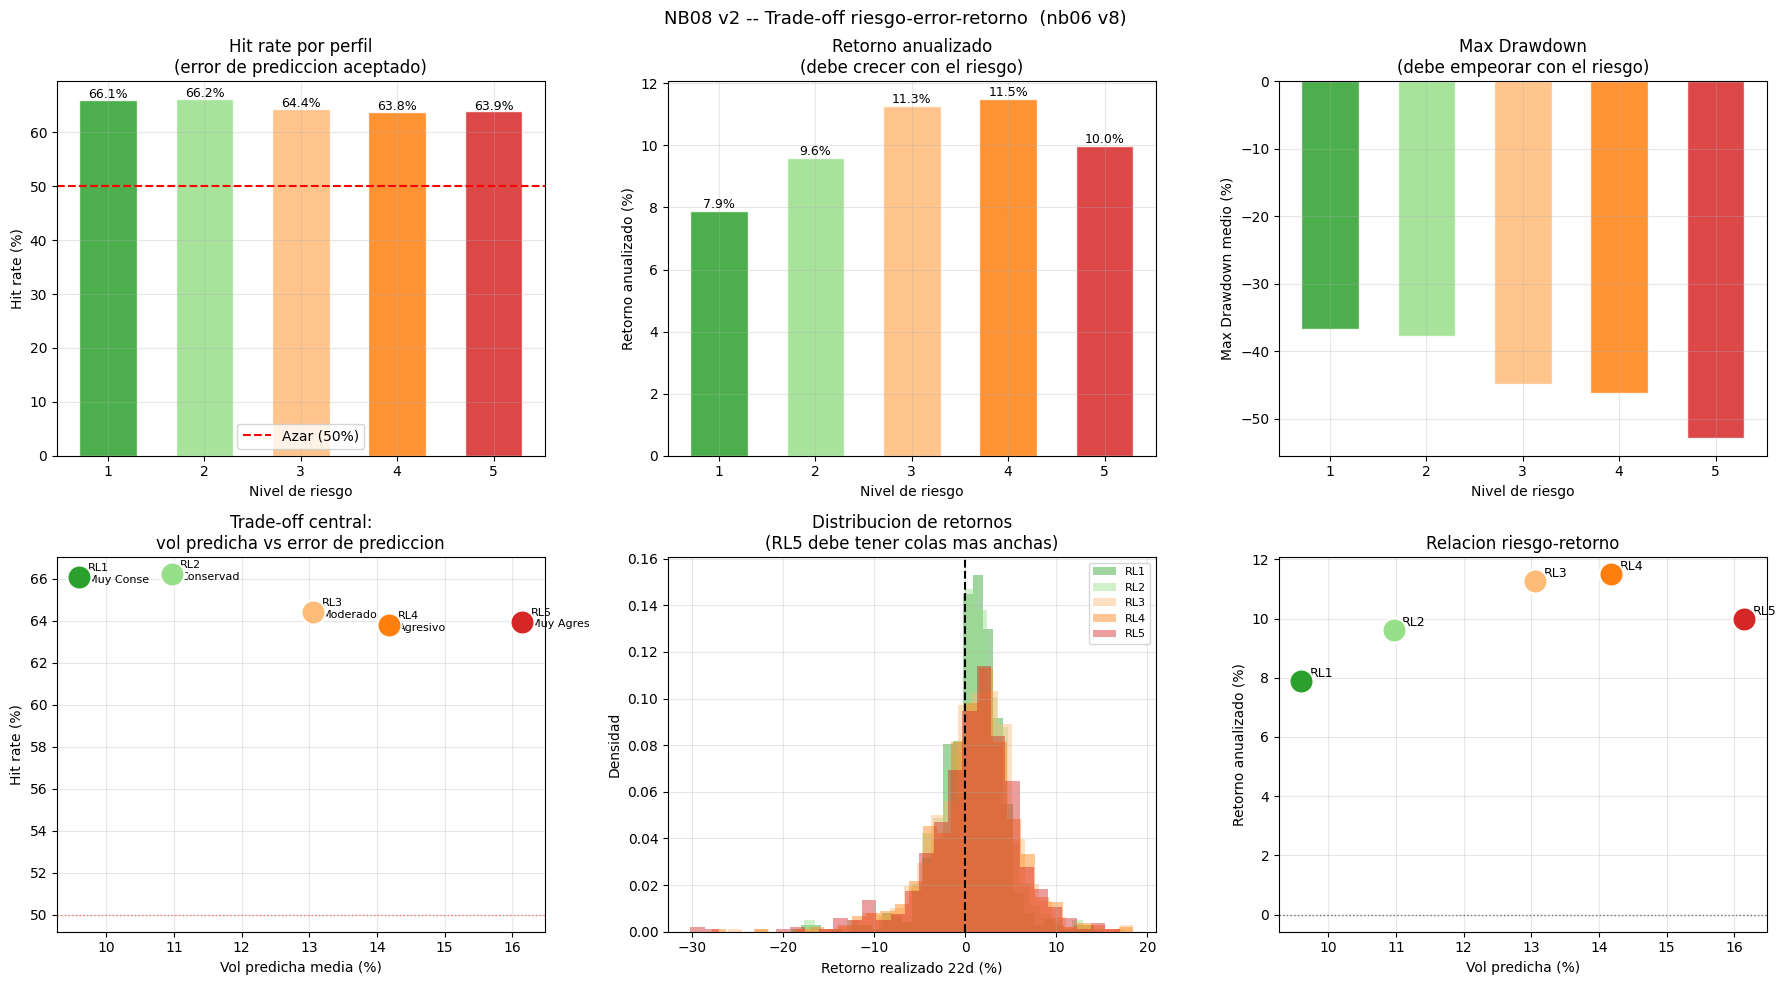

In [5]:
colors = {1:'#2ca02c', 2:'#98df8a', 3:'#ffbb78', 4:'#ff7f0e', 5:'#d62728'}
rls = list(results_by_risk.keys())
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Hit rate por nivel (debe decrecer o mantenerse)
ax = axes[0,0]
hr = [results_by_risk[rl]['metrics'].get('overall_hit_rate',0)*100 for rl in rls]
bars = ax.bar(rls, hr, color=[colors[rl] for rl in rls], alpha=0.85, edgecolor='white', width=0.6)
ax.axhline(50, color='red', ls='--', lw=1.5, label='Azar (50%)')
for bar, v in zip(bars, hr):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{v:.1f}%", ha='center', fontsize=9)
ax.set_xlabel('Nivel de riesgo'); ax.set_ylabel('Hit rate (%)')
ax.set_title('Hit rate por perfil\n(error de prediccion aceptado)'); ax.legend(); ax.grid(alpha=0.3)

# Retorno anualizado (debe crecer)
ax = axes[0,1]
ann = [results_by_risk[rl]['metrics'].get('annualized_return',0)*100 for rl in rls]
bars = ax.bar(rls, ann, color=[colors[rl] for rl in rls], alpha=0.85, edgecolor='white', width=0.6)
for bar, v in zip(bars, ann):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f"{v:.1f}%", ha='center', fontsize=9)
ax.set_xlabel('Nivel de riesgo'); ax.set_ylabel('Retorno anualizado (%)')
ax.set_title('Retorno anualizado\n(debe crecer con el riesgo)'); ax.grid(alpha=0.3)

# MaxDD (debe empeorar)
ax = axes[0,2]
mdd = [results_by_risk[rl]['dd'].mean()*100 if len(results_by_risk[rl]['dd'])>0 else 0 for rl in rls]
bars = ax.bar(rls, mdd, color=[colors[rl] for rl in rls], alpha=0.85, edgecolor='white', width=0.6)
for bar, v in zip(bars, mdd):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1.5, f"{v:.1f}%",
            ha='center', fontsize=9, color='white')
ax.set_xlabel('Nivel de riesgo'); ax.set_ylabel('Max Drawdown medio (%)')
ax.set_title('Max Drawdown\n(debe empeorar con el riesgo)'); ax.grid(alpha=0.3)

# Trade-off central: vol predicha vs hit rate
ax = axes[1,0]
vols = [results_by_risk[rl]['mean_pred_vol']*100 for rl in rls]
for rl, v, h in zip(rls, vols, hr):
    ax.scatter(v, h, color=colors[rl], s=300, zorder=4, edgecolors='white', lw=1.5)
    ax.annotate(f"RL{rl}\n{LEVEL_NAMES[rl][:9]}", (v,h), textcoords='offset points',
                xytext=(6,-4), fontsize=8)
ax.axhline(50, color='red', ls=':', lw=1, alpha=0.5)
ax.set_xlabel('Vol predicha media (%)'); ax.set_ylabel('Hit rate (%)')
ax.set_title('Trade-off central:\nvol predicha vs error de prediccion'); ax.grid(alpha=0.3)

# Distribucion de retornos
ax = axes[1,1]
for rl in rls:
    ax.hist(results_by_risk[rl]['bt']['realized_return']*100, bins=30,
            alpha=0.45, color=colors[rl], label=f'RL{rl}', density=True)
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.set_xlabel('Retorno realizado 22d (%)'); ax.set_ylabel('Densidad')
ax.set_title('Distribucion de retornos\n(RL5 debe tener colas mas anchas)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Vol vs retorno
ax = axes[1,2]
for rl, v, a in zip(rls, vols, ann):
    ax.scatter(v, a, color=colors[rl], s=300, zorder=4, edgecolors='white', lw=1.5)
    ax.annotate(f"RL{rl}", (v,a), textcoords='offset points', xytext=(6,3), fontsize=9)
ax.axhline(0, color='black', ls=':', lw=1, alpha=0.5)
ax.set_xlabel('Vol predicha (%)'); ax.set_ylabel('Retorno anualizado (%)')
ax.set_title('Relacion riesgo-retorno'); ax.grid(alpha=0.3)

plt.suptitle(f'NB08 v2 -- Trade-off riesgo-error-retorno  (nb06 {source_version})', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_validation_v2.png', dpi=150)
plt.show()

## 5. Composición de carteras recomendadas por perfil de riesgo

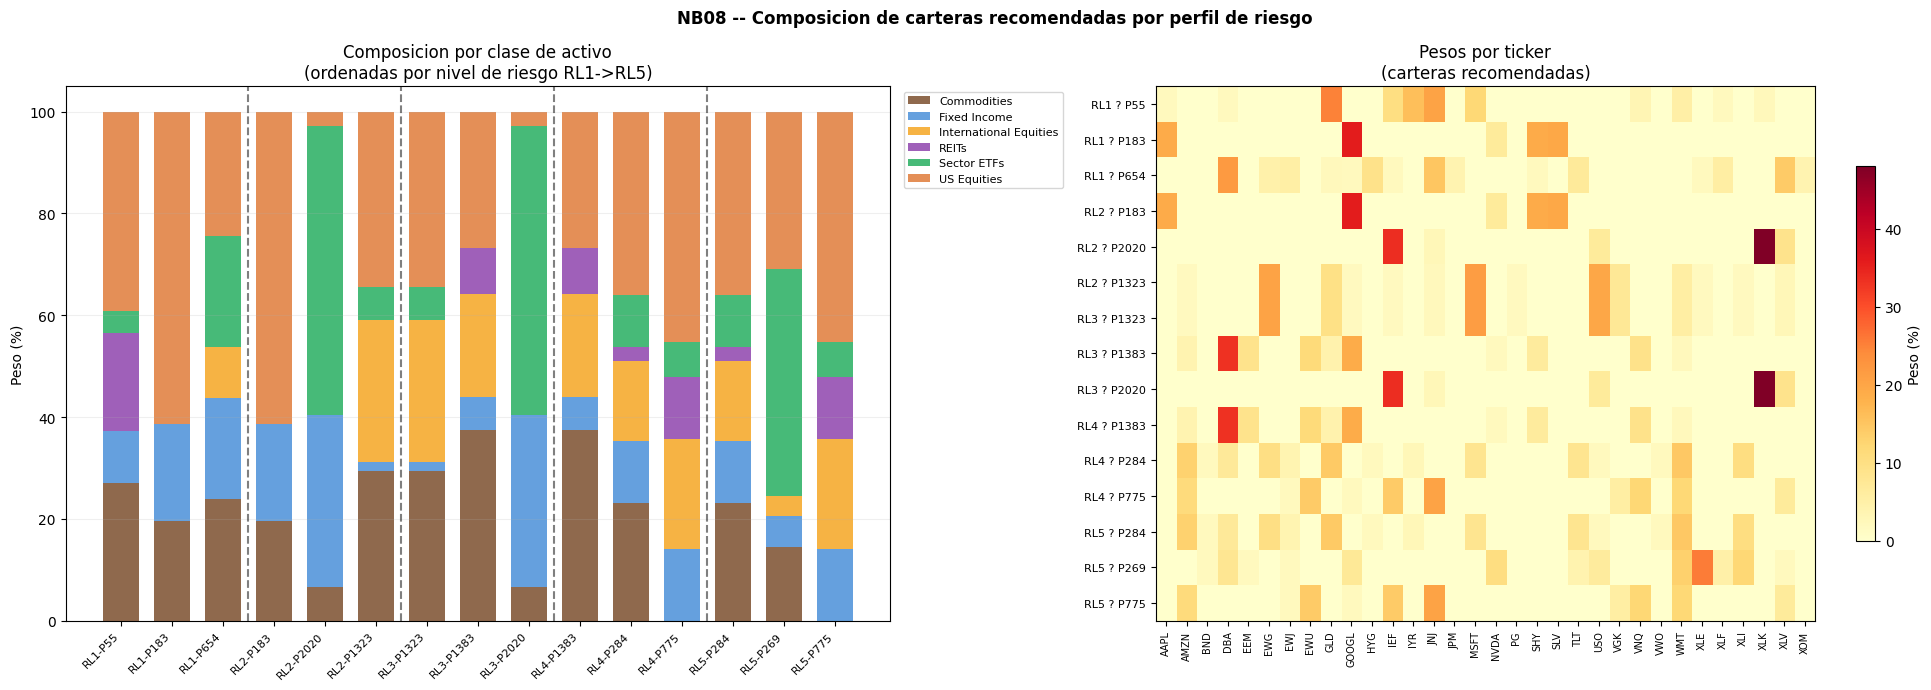

[OK] 08_composition_by_risk.png

=== Peso medio por clase de activo y nivel de riesgo (%) ===
            Commodities  Fixed Income  International Equities  REITs  Sector ETFs  US Equities
risk_level                                                                                    
1                  23.5          16.4                     3.3    6.4          8.6         41.7
2                  18.5          18.2                     9.3    0.0         21.1         32.9
3                  24.5          14.0                    16.0    3.0         21.1         21.3
4                  20.2          11.0                    19.2    8.0          5.7         36.0
5                  12.6          10.8                    13.7    5.0         20.6         37.4


In [6]:
# -- Composicion de las 15 carteras recomendadas (3 por nivel) -----------------
import json as _json

port_comp   = pd.read_parquet(PROCESSED_DIR / 'portfolios_composition.parquet')
port_comp['portfolio_id'] = port_comp['portfolio_id'].astype(int)

asset_meta   = _json.loads((PROCESSED_DIR / 'asset_universe.json').read_text())
ticker_class = asset_meta.get('asset_classes', {})   # {ticker: 'US Equities', ...}

rec_pids = recs_df['portfolio_id'].astype(int).unique()
comp_rec = port_comp[port_comp['portfolio_id'].isin(rec_pids)].copy()
comp_rec['asset_class'] = comp_rec['ticker'].map(ticker_class).fillna('Other')

# Pesos agregados por (portfolio_id, clase)
comp_agg = (comp_rec.groupby(['portfolio_id', 'asset_class'])['weight']
                    .sum().unstack(fill_value=0))

# Pesos por ticker individual (para heatmap)
comp_ticker = (comp_rec.pivot_table(index='portfolio_id', columns='ticker',
                                    values='weight', fill_value=0))

# Anadir nivel de riesgo y ordenar
pid_rl = recs_df[['portfolio_id', 'risk_level']].drop_duplicates()
pid_rl['portfolio_id'] = pid_rl['portfolio_id'].astype(int)
comp_agg    = comp_agg.join(pid_rl.set_index('portfolio_id')['risk_level']).sort_values('risk_level')
comp_ticker = comp_ticker.join(pid_rl.set_index('portfolio_id')['risk_level']).sort_values('risk_level')

CLASS_COLORS = {
    'US Equities':            '#e07b39',
    'International Equities': '#f5a623',
    'Fixed Income':           '#4a90d9',
    'Commodities':            '#7b4f2e',
    'REITs':                  '#8e44ad',
    'Sector ETFs':            '#27ae60',
    'Other':                  '#95a5a6',
}
asset_cols = [c for c in comp_agg.columns if c != 'risk_level']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# -- Subplot izquierdo: stacked bar por cartera ordenada por nivel --------------
ax = axes[0]
bottom = np.zeros(len(comp_agg))
for cls in asset_cols:
    vals = comp_agg[cls].values
    ax.bar(range(len(comp_agg)), vals * 100, bottom=bottom * 100,
           label=cls, color=CLASS_COLORS.get(cls, '#bdc3c7'), alpha=0.85, width=0.7)
    bottom += vals

prev_rl = None
for i, rl in enumerate(comp_agg['risk_level'].values):
    if prev_rl is not None and rl != prev_rl:
        ax.axvline(i - 0.5, color='black', lw=1.5, ls='--', alpha=0.5)
    prev_rl = rl

x_labels = [
    'RL' + str(int(comp_agg['risk_level'].iloc[i])) + '-P' + str(comp_agg.index[i])
    for i in range(len(comp_agg))
]
ax.set_xticks(range(len(comp_agg)))
ax.set_xticklabels(x_labels, fontsize=8, rotation=45, ha='right')
ax.set_ylabel('Peso (%)')
ax.set_ylim(0, 105)
ax.set_title('Composicion por clase de activo\n(ordenadas por nivel de riesgo RL1->RL5)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(alpha=0.2, axis='y')

# -- Subplot derecho: heatmap de pesos por ticker -------------------------------
ax = axes[1]
tickers_plot = [c for c in comp_ticker.columns if c != 'risk_level']
data_h = comp_ticker[tickers_plot].values * 100
im = ax.imshow(data_h, cmap='YlOrRd', aspect='auto', vmin=0)
ax.set_xticks(range(len(tickers_plot)))
ax.set_xticklabels(tickers_plot, rotation=90, fontsize=7)
y_labels = [
    'RL' + str(int(comp_ticker['risk_level'].iloc[i])) + ' ? P' + str(comp_ticker.index[i])
    for i in range(len(comp_ticker))
]
ax.set_yticks(range(len(comp_ticker)))
ax.set_yticklabels(y_labels, fontsize=8)
ax.set_title('Pesos por ticker\n(carteras recomendadas)')
plt.colorbar(im, ax=ax, label='Peso (%)', shrink=0.7)

plt.suptitle('NB08 -- Composicion de carteras recomendadas por perfil de riesgo',
             fontsize=12, fontweight='bold')
plt.tight_layout()
out_comp = FIG_DIR / '08_composition_by_risk.png'
plt.savefig(out_comp, dpi=150, bbox_inches='tight')
plt.show()
print('[OK] ' + out_comp.name)

# Resumen: distribucion media por clase y nivel de riesgo
print('\n=== Peso medio por clase de activo y nivel de riesgo (%) ===')
summary_comp = comp_agg.groupby('risk_level')[asset_cols].mean() * 100
print(summary_comp.round(1).to_string())


## 6. Guardar outputs

In [7]:
# === Comparacion ENS baseline vs hibrido ENS+consenso ===
print('=== Comparacion de versiones de recomendacion ===')
bt_df = pd.concat([r['bt'].assign(risk_level=rl) for rl, r in results_by_risk.items()], ignore_index=True)
by_risk = compute_by_risk(bt_df, recs_df)
dd_series = compute_drawdown_stats(bt_df)
metrics = compute_validation_metrics(bt_df, HORIZON_DAYS)
crisis_metrics = {}
crisis_by_risk = {}
_recs_baseline = None
for _fname in ['recommendations_v6.parquet', 'recommendations_v5.parquet']:
    _p = RESULTS_DIR / _fname
    if _p.exists():
        _recs_baseline = pd.read_parquet(_p)
        print(f'Baseline: {_fname}')
        break

if _recs_baseline is not None:
    try:
        comp_df = compare_recommendation_versions(bt_df, _recs_baseline, recs_df)
        print()
        print(comp_df.to_string())
    except Exception as _e:
        print(f'[WARN] compare_recommendation_versions: {_e}')
        for _rl in sorted(recs_df['risk_level'].dropna().astype(int).unique()):
            _sub = bt_df[bt_df['risk_level'] == _rl]
            _hit = _sub['hit'].mean() if len(_sub) > 0 else float('nan')
            _ann = _sub['realized_return'].mean() * (252 / HORIZON_DAYS) if len(_sub) > 0 else float('nan')
            _pids = recs_df[recs_df['risk_level'] == _rl]['portfolio_id'].astype(int).tolist()
            print(f'  Risk {_rl}: hit={_hit:.4f}  ann_ret={_ann:.4f}  portfolios={_pids}')
else:
    print('[INFO] No baseline recommendations found for comparison')

for crisis_name, (c_start, c_end) in CRISIS_WINDOWS.items():
    print(f'\n--- {crisis_name}: {c_start} a {c_end} ---')
    crisis_metrics[crisis_name] = run_crisis_backtest(bt_df, crisis_name, c_start, c_end)
    crisis_by_risk[crisis_name] = run_crisis_backtest_by_risk(bt_df, recs_df, crisis_name, c_start, c_end)
    cbr = crisis_by_risk[crisis_name]
    if len(cbr) > 0:
        print(cbr[['risk_level','hit_rate','ann_return','mean_max_dd','n_obs']].round(4).to_string(index=False))

full_by_risk = by_risk.reset_index()
plot_crisis_comparison(full_by_risk, crisis_by_risk, FIG_DIR)
save_backtest_outputs_v5(bt_df, metrics, dd_series, crisis_metrics, RESULTS_DIR)
print('[OK] Comparacion completada')


=== Comparacion de versiones de recomendacion ===
Baseline: recommendations_v5.parquet

            hit_rate_new  ann_return_new      portfolios_new portfolios_baseline  portfolios_changed
risk_level                                                                                          
1                 0.6606          0.0761      [55, 183, 654]     [548, 646, 668]                True
2                 0.6621          0.0920   [183, 1323, 2020]               [668]                True
3                 0.6439          0.1072  [1323, 1383, 2020]     [502, 646, 668]                True
4                 0.6379          0.1094    [284, 775, 1383]    [646, 668, 1364]                True
5                 0.6394          0.0955     [269, 284, 775]    [502, 668, 1364]                True

--- COVID-2020: 2020-01-15 a 2020-06-30 ---
  [COVID-2020] n=75  hit=0.800  ann_ret=13.5%  maxDD=-12.4%
 risk_level  hit_rate  ann_return  mean_max_dd  n_obs
          1       0.8      0.0478      -0.2242

In [8]:
all_bt = pd.concat(
    [r["bt"].assign(risk_level=rl) for rl, r in results_by_risk.items()],
    ignore_index=True
)

# Guardar backtest completo
all_bt.to_parquet(RESULTS_DIR / "backtest_results_v7.parquet", index=False)

mape_cols = [
    ("M1", "M1_mape_pct"),
    ("M2", "M2_mape_pct"),
    ("M3", "M3_mape_pct"),
    ("M4", "M4_mape_pct"),
    ("ENS", "ENS_mape_pct"),
]
mean_mape_pct = {
    label: round(float(model_results[col].mean()), 4)
    for label, col in mape_cols
    if col in model_results.columns
}

summary = {
    "version":        "v7",
    "source_version": source_version,
    "horizon_days":   HORIZON_DAYS,
    "mean_mape_pct":  mean_mape_pct,
    "by_risk_level": {
        str(rl): {
            "portfolio_ids":     r["pids"],
            "mean_pred_vol_pct": round(r["mean_pred_vol"] * 100, 2),
            "hit_rate":          round(r["metrics"].get("overall_hit_rate", 0), 4),
            "mean_realized_ret": round(r["metrics"].get("mean_realized_ret", 0), 4),
            "annualized_return": round(r["metrics"].get("annualized_return", 0), 4),
            "backtest_sharpe":   round(r["metrics"].get("backtest_sharpe", 0), 4),
            "mean_max_drawdown": round(float(r["dd"].mean()), 4) if len(r["dd"]) > 0 else None,
            "n_observations":    r["metrics"].get("n_observations", 0),
        } for rl, r in results_by_risk.items()
    },
}
summary["crisis_periods"] = {name: {k: (float(v) if isinstance(v, (int, float)) else v) for k, v in cm.items()} for name, cm in crisis_metrics.items()}
with open(RESULTS_DIR / "backtest_summary_v7.json", "w") as f:
    json.dump(summary, f, indent=2)

print("[OK] backtest_results_v7.parquet")
print("[OK] backtest_summary_v7.json")
print("")
print("=== MAPE medio por modelo ===")
if mean_mape_pct:
    print(pd.Series(mean_mape_pct).sort_index().to_string())
print("")
print("=== Resumen para juzgar perfiles ===")
risk_summary = tradeoff[["Vol pred (%)", "Hit rate (%)", "Ret 22d (%)", "Ann ret (%)", "Sharpe", "MaxDD (%)"]].copy()
risk_summary = risk_summary.sort_values(["Ann ret (%)", "Sharpe"], ascending=[False, False])
print(risk_summary.to_string())
print("")
print("NB08 v7 COMPLETE")
print(tradeoff[["Vol pred (%)","Hit rate (%)","Ret 22d (%)","Ann ret (%)","Sharpe","MaxDD (%)"]].to_string())


[OK] backtest_results_v7.parquet
[OK] backtest_summary_v7.json

=== MAPE medio por modelo ===
ENS    222.0694
M1     231.1309
M2     442.5974
M3     124.6582
M4     350.8588

=== Resumen para juzgar perfiles ===
      Vol pred (%)  Hit rate (%)  Ret 22d (%)  Ann ret (%)  Sharpe  MaxDD (%)
Risk                                                                         
4             14.2          63.8         0.95         11.5   0.679      -46.2
3             13.1          64.4         0.94         11.3   0.696      -44.8
5             16.1          63.9         0.83         10.0   0.556      -52.8
2             11.0          66.2         0.80          9.6   0.716      -37.7
1              9.6          66.1         0.66          7.9   0.633      -36.7

NB08 v7 COMPLETE
      Vol pred (%)  Hit rate (%)  Ret 22d (%)  Ann ret (%)  Sharpe  MaxDD (%)
Risk                                                                         
1              9.6          66.1         0.66          7.9   0.633  

---
## Limitación: sesgos en el análisis de crisis

**Las 40 carteras fueron seleccionadas en N04 usando el período completo 2007-2026.**
Esto introduce dos sesgos en el backtest de crisis:

1. **Sesgo de supervivencia:** solo se incluyen carteras que sobrevivieron y se recuperaron del GFC (2008) y COVID (2020).

2. **Sesgo de look-ahead:** N04 ya conocía el rendimiento post-crisis al seleccionar las carteras. Un sistema real desplegado en 2008 no habría tenido esa información.

El análisis de crisis muestra el comportamiento de **carteras seleccionadas retrospectivamente**, no la actuación que habría tenido el sistema en tiempo real.

> El backtest walk-forward de N06 (predicción de crecimiento) sí es metodológicamente correcto: usa purging + embargo para evitar leakage.

---


In [9]:
# Resumen final de crisis y validacion
if 'bt_df' not in globals():
    bt_df = pd.concat([r['bt'].assign(risk_level=rl) for rl, r in results_by_risk.items()], ignore_index=True)
if 'by_risk' not in globals():
    by_risk = compute_by_risk(bt_df, recs_df)
if 'dd_series' not in globals():
    dd_series = compute_drawdown_stats(bt_df)
if 'crisis_metrics' not in globals():
    crisis_metrics = {}
if 'crisis_by_risk' not in globals():
    crisis_by_risk = {}

print('=== Backtest de crisis ===')
for crisis_name, (c_start, c_end) in CRISIS_WINDOWS.items():
    if crisis_name not in crisis_metrics:
        crisis_metrics[crisis_name] = run_crisis_backtest(bt_df, crisis_name, c_start, c_end)
    if crisis_name not in crisis_by_risk:
        crisis_by_risk[crisis_name] = run_crisis_backtest_by_risk(bt_df, recs_df, crisis_name, c_start, c_end)
    cbr = crisis_by_risk[crisis_name]
    if len(cbr) > 0:
        print(cbr[['risk_level','hit_rate','ann_return','mean_max_dd','n_obs']].round(4).to_string(index=False))

print('\n=== Comparativa: periodo completo vs crisis ===')
plot_crisis_comparison(by_risk.reset_index(), crisis_by_risk, FIG_DIR)
print('[OK] Crisis backtest completado')


=== Backtest de crisis ===
 risk_level  hit_rate  ann_return  mean_max_dd  n_obs
          1       0.8      0.0478      -0.2242     20
          2       0.8      0.3220      -0.1376     20
          4       0.8      0.2266      -0.1092     15
          5       0.8     -0.0446       0.0000      5
 risk_level  hit_rate  ann_return  mean_max_dd  n_obs
          1    0.2857     -0.3740      -0.5518     28
          2    0.2857     -0.2515      -0.4482     28
          4    0.2857     -0.3178      -0.4199     21
          5    0.2857     -0.2892      -0.2403      7

=== Comparativa: periodo completo vs crisis ===
Saved: C:\Users\Usuario\Documents\TFG\tfg_xiker_code\data\results\figures\08_crisis_comparison.png
[OK] Crisis backtest completado


## 7. Validación out-of-sample: período reciente (2025-2026)

In [10]:
# Validacion out-of-sample: ventanas de enero 2025 en adelante
# backtest_results_v4 cubre hasta 2026-03-02; estas ventanas son fuera del
# entrenamiento walk-forward original (modelos entrenados hasta dic-2021).
_bt_v4_full = pd.read_parquet(RESULTS_DIR / 'backtest_results_v4.parquet')
_oos_cutoff = pd.Timestamp('2025-01-01')
_bt_oos = _bt_v4_full[_bt_v4_full['start_date'] >= _oos_cutoff].copy()

if len(_bt_oos) == 0:
    print('No hay ventanas out-of-sample disponibles en backtest_results_v4.')
else:
    print(f'Ventanas OOS 2025-2026: {len(_bt_oos)} '
          f'({_bt_oos["start_date"].min().date()} -> {_bt_oos["start_date"].max().date()})')
    print()

    _hist_hits = {1: 0.661, 2: 0.662, 3: 0.644, 4: 0.638, 5: 0.639}
    _hist_rets = {1: 7.9,   2: 9.6,   3: 11.3,  4: 11.5,  5: 10.0}

    _oos_rows = []
    for _lvl in [1, 2, 3, 4, 5]:
        _sub = _bt_oos[_bt_oos['risk_level'] == _lvl]
        if len(_sub) == 0:
            continue
        _hit      = _sub['hit'].mean()
        _ret_mean = _sub['realized_return'].mean()
        _ret_ann  = (1 + _ret_mean) ** (252 / 22) - 1
        _n        = len(_sub)
        _delta_h  = (_hit - _hist_hits[_lvl]) * 100
        _oos_rows.append({
            'Nivel': _lvl, 'Perfil': LEVEL_NAMES[_lvl],
            'N ventanas': _n,
            'Hit OOS (%)': round(_hit * 100, 1),
            'Hit hist (%)': round(_hist_hits[_lvl] * 100, 1),
            'Delta hit (pp)': round(_delta_h, 1),
            'Ret anual OOS (%)': round(_ret_ann * 100, 1),
            'Ret anual hist (%)': _hist_rets[_lvl],
        })
        print(f'R{_lvl}: N={_n}  hit_oos={_hit*100:.1f}%  hit_hist={_hist_hits[_lvl]*100:.1f}%  delta={_delta_h:+.1f}pp  ret_ann={_ret_ann*100:.1f}%')

    if _oos_rows:
        _oos_df = pd.DataFrame(_oos_rows).set_index('Nivel')
        print()
        print(_oos_df.to_string())


Ventanas OOS 2025-2026: 210 (2025-01-07 -> 2026-03-02)

R1: N=42  hit_oos=71.4%  hit_hist=66.1%  delta=+5.3pp  ret_ann=16.3%
R2: N=42  hit_oos=66.7%  hit_hist=66.2%  delta=+0.5pp  ret_ann=13.0%
R3: N=42  hit_oos=64.3%  hit_hist=64.4%  delta=-0.1pp  ret_ann=10.1%
R4: N=42  hit_oos=64.3%  hit_hist=63.8%  delta=+0.5pp  ret_ann=11.7%
R5: N=42  hit_oos=66.7%  hit_hist=63.9%  delta=+2.8pp  ret_ann=16.7%

                Perfil  N ventanas  Hit OOS (%)  Hit hist (%)  Delta hit (pp)  Ret anual OOS (%)  Ret anual hist (%)
Nivel                                                                                                               
1      Muy Conservador          42         71.4          66.1             5.3               16.3                 7.9
2          Conservador          42         66.7          66.2             0.5               13.0                 9.6
3             Moderado          42         64.3          64.4            -0.1               10.1                11.3
4            